# Tworzenie dataframe

In [24]:
import pandas as pd
import numpy as np
from PIL import Image
from pathlib import Path
import cv2

In [19]:
SAVE_DIR = Path("outputs")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

In [36]:
masks_array = np.load(str(SAVE_DIR)+'/masks_array.npy')
incomplete_detect = np.load(str(SAVE_DIR)+'/incomplete_detect.npy')
df = pd.read_csv(str(SAVE_DIR)+'/df.csv')
incomplete_detect

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  21,  28,  34,
        42,  49,  57,  58,  59,  66,  68,  70,  72,  88,  89,  90,  91,
        96, 103, 104, 108, 111, 112, 113, 114, 115, 116, 117, 118, 119,
       120, 123, 152])

## (x,y) z GDSAM

In [34]:
xy_array = []

for i in range(0, masks_array.shape[0]):

  # Załadowanie obrazu głębokości
  depth_img = Image.open(df['depth_path'][i]).convert("RGB")
  depth_img = np.asarray(depth_img)
  depth_img = depth_img[:, :, 0]

  tmp = []

  for j in range(0, masks_array.shape[1]):

    # Utworzenie maski
    mask = (masks_array[i][j] * depth_img)
  
    # Obliczanie momentów
    moments = cv2.moments(mask)

    # Wysokość maski
    y_indices, x_indices = np.where(mask > 0)
    if len(y_indices) == 0 or len(x_indices) == 0:
      tmp.extend([0, 0,])
      continue
    mask_height = np.max(y_indices) - np.min(y_indices) + 1
    mask_width = np.max(x_indices) - np.min(x_indices) + 1

    # Momenty centralne
    m10 = moments['m10']
    m01 = moments['m01']
    m00 = moments['m00']

    # Środki masy
    if m00 == 0:
      tmp.extend([0, 0,])
    else:
      x = m10/m00
      y = m01/m00
      #z = np.mean(mask[mask > 0])
      tmp.extend([x, y])
  xy_array.append(tmp)

xy_array = np.array(xy_array)
print(f"xy_array shape -> {xy_array.shape}")

xy_array shape -> (172, 6)


In [55]:
xy_array = np.delete(xy_array, incomplete_detect, axis=0)
xy_array.shape

(130, 6)

## (x,y) z GPT

### Tworzenie input_image do API openai

In [177]:
import base64
from openai import OpenAI
import os

client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

In [178]:
# Function to encode the image
def encode_image(image_path):
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode("utf-8")

In [179]:
encoded_images = df["color_path"].apply(encode_image).to_numpy().reshape(-1,1)
encoded_images.shape

(172, 1)

In [180]:
encoded_images = np.delete(encoded_images, incomplete_detect, axis=0)
encoded_images.shape

(130, 1)

In [181]:
xy_array_gpt = []
for i in range(0, 10):#encoded_images.shape[0]):
    base64_image = encoded_images[i][0]
    
    prompt_text = (
        "Na poniższym obrazie znajduje się chwytak robota z trzema kolorowymi elementami: różowym, zielonym i niebieskim. "
        "Podaj znormalizowane współrzędne środków tych elementów w kolejności: różowy, zielony, niebieski. "
        "Format odpowiedzi: (x,y),(x,y),(x,y)"
    )

    response = client.responses.create(
        model="gpt-5",
        input=[
            {
                "role": "user",
                "content": [
                    { "type": "input_text", "text": prompt_text },
                    {
                        "type": "input_image",
                        "image_url": f"data:image/jpeg;base64,{base64_image}",
                    },
                ],
            }
        ],
    )
    xy_array_gpt.append(response.output_text)

In [182]:
xy_array_gpt = np.array(xy_array_gpt).reshape(-1,1)
xy_array_gpt.shape

(10, 1)

In [183]:
xy_array_gpt[0]

array(['(0.48,0.27),(0.51,0.21),(0.55,0.28)'], dtype='<U35')

In [185]:
#np.save(str(SAVE_DIR)+'/xy_array_gpt.npy', xy_array_gpt)
xy_array_gpt = np.load(str(SAVE_DIR)+'/xy_array_gpt.npy')

In [186]:
import re

result = []

for row in xy_array_gpt:
    text = row[0]
    # Wyciągnij pary liczb zmiennoprzecinkowych
    pairs = re.findall(r'\(([\d.]+),\s*([\d.]+)\)', text)
    # Zamień na float i dodaj do wyniku
    numbers = [float(x) for pair in pairs for x in pair]
    result.append(numbers)

xy_array_gpt_num = np.array(result)

print("Wynikowy array kształtu:", xy_array_gpt_num.shape)
print(xy_array_gpt_num)

Wynikowy array kształtu: (10, 6)
[[0.48 0.27 0.51 0.21 0.55 0.28]
 [0.59 0.26 0.62 0.24 0.66 0.27]
 [0.72 0.3  0.75 0.3  0.78 0.31]
 [0.55 0.36 0.51 0.32 0.6  0.38]
 [0.58 0.47 0.6  0.42 0.62 0.48]
 [0.56 0.25 0.6  0.25 0.65 0.26]
 [0.55 0.26 0.58 0.28 0.61 0.31]
 [0.56 0.44 0.59 0.4  0.62 0.47]
 [0.54 0.47 0.5  0.43 0.59 0.48]
 [0.45 0.66 0.5  0.64 0.56 0.67]]


# Wizualizacja

In [187]:
import matplotlib.pyplot as plt

In [188]:
id_array = np.delete(np.arange(172), incomplete_detect, axis=0)
id_array.shape

(130,)

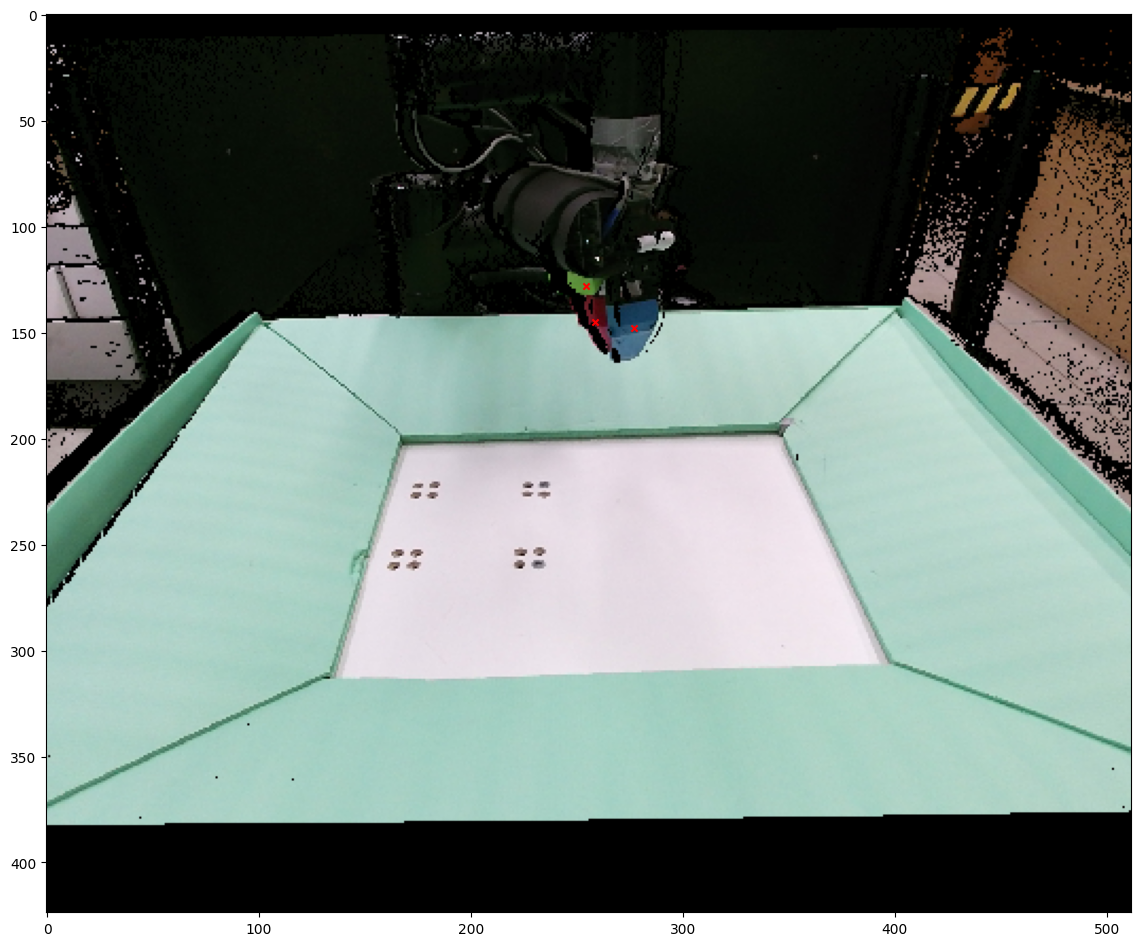

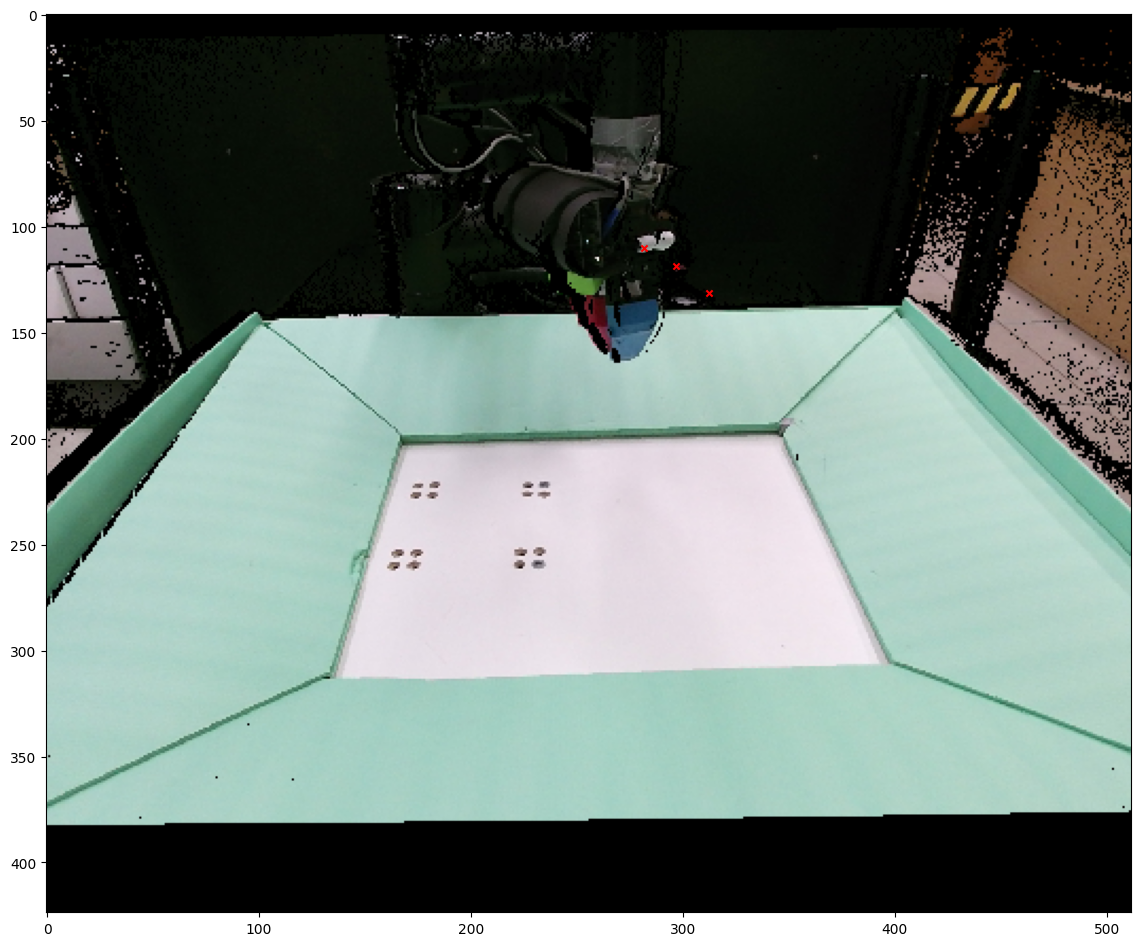

In [194]:
nr_xy = 6

plt.figure(figsize=(14, 14))
plt.imshow(cv2.cvtColor(cv2.imread(df['color_path'][id_array[nr_xy]]), cv2.COLOR_BGR2RGB))
plt.scatter(xy_array[nr_xy][0], xy_array[nr_xy][1], color='red', marker='x', s=20)  # Różowy
plt.scatter(xy_array[nr_xy][2], xy_array[nr_xy][3], color='red', marker='x', s=20)  # Zielony
plt.scatter(xy_array[nr_xy][4], xy_array[nr_xy][5], color='red', marker='x', s=20)  # Niebieski
plt.show()

plt.figure(figsize=(14, 14))
plt.imshow(cv2.cvtColor(cv2.imread(df['color_path'][id_array[nr_xy]]), cv2.COLOR_BGR2RGB))
#plt.imshow(cv2.resize(cv2.cvtColor(cv2.imread(df['color_path'][id_array[nr_xy]]), cv2.COLOR_BGR2RGB), (512, 512)))
plt.scatter(xy_array_gpt_num[nr_xy][0]*512, xy_array_gpt_num[nr_xy][1]*424, color='red', marker='x', s=20)  # Różowy
plt.scatter(xy_array_gpt_num[nr_xy][2]*512, xy_array_gpt_num[nr_xy][3]*424, color='red', marker='x', s=20)  # Zielony
plt.scatter(xy_array_gpt_num[nr_xy][4]*512, xy_array_gpt_num[nr_xy][5]*424, color='red', marker='x', s=20)  # Niebieski
plt.show()